![image info](https://raw.githubusercontent.com/albahnsen/MIAD_ML_and_NLP/main/images/banner_1.png)

# Taller: Construcción e implementación de árboles de decisión y métodos de ensamblaje

En este taller podrá poner en práctica los sus conocimientos sobre construcción e implementación de árboles de decisión y métodos de ensamblajes. El taller está constituido por 9 puntos, 5 relacionados con árboles de decisión (parte A) y 4 con métodos de ensamblaje (parte B).

## Parte A - Árboles de decisión

En esta parte del taller se usará el conjunto de datos de Capital Bikeshare de Kaggle, donde cada observación representa el alquiler de bicicletas durante una hora y día determinado. Para más detalles puede visitar los siguientes enlaces: [datos](https://archive.ics.uci.edu/ml/machine-learning-databases/00275/Bike-Sharing-Dataset.zip), [dicccionario de datos](https://archive.ics.uci.edu/ml/datasets/Bike+Sharing+Dataset#).

### Datos prestamo de bicicletas

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Importación de librerías
%matplotlib inline
import pandas as pd
import numpy as np
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor, export_graphviz

In [3]:
# Lectura de la información de archivo .csv
bikes = pd.read_csv('https://raw.githubusercontent.com/davidzarruk/MIAD_ML_NLP_2023/main/datasets/bikeshare.csv', index_col='datetime', parse_dates=True)

# Renombrar variable "count" a "total"
bikes.rename(columns={'count':'total'}, inplace=True)

# Crear la hora como una variable
bikes['hour'] = bikes.index.hour

# Visualización de los datos
bikes.head()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,total,hour
datetime,,,,,,,,,,,,
2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16,0
2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40,1
2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32,2
2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13,3
2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1,4


### Punto 1 - Análisis descriptivo

Ejecute las celdas 1.1 y 1.2. A partir de los resultados realice un análisis descriptivo sobre las variables "season" y "hour", escriba sus inferencias sobre los datos. Para complementar su análisis puede usar métricas como máximo, mínimo, percentiles entre otros.

In [4]:
# Celda 1.1
bikes.groupby('season').total.mean()

,total
season,
1,116.343261
2,215.251372
3,234.417124
4,198.988296


Teniendo en cuenta la correspondencia de la variable **season** con las estaciones (1:winter, 2:spring, 3:summer, 4:fall), es posible inferir que las personas tienden a utilizar más las bicicletas durante las temporadas más calidas (verano y primavera) y menos en las temporadas más frías (invierno y otoño).

In [5]:
# Celda 1.2
bikes.groupby('hour').total.mean()

,total
hour,
0,55.138462
1,33.859031
2,22.899554
3,11.757506
4,6.407240
5,19.767699
6,76.259341
7,213.116484
8,362.769231


In [6]:
mean_by_hour = bikes.groupby('hour').total.mean()

print(f'El valor máximo del promedio se presentra a las {mean_by_hour.idxmax()} horas: {mean_by_hour.max():.0f}')
print(f'El valor mínimo del promedio se presentra a las {mean_by_hour.idxmin()} horas: {mean_by_hour.min():.0f}')

El valor máximo del promedio se presentra a las 17 horas: 469
El valor mínimo del promedio se presentra a las 4 horas: 6


In [7]:
(mean_by_hour.cumsum() / mean_by_hour.sum()).round(2)

,total
hour,
0,0.01
1,0.02
2,0.02
3,0.03
4,0.03
5,0.03
6,0.05
7,0.10
8,0.18


Con respecto a la variable **hour** es posible inferir que los usuarios aumentan el uso de las bicicletas en la medida que transcurre el día, teniendo sus valores mínimos de uso en horas de la madrugada y los máximos en horas de la tarde, probablemente asociado a la finalización de jornadas de trabajo y estudio.

### Punto 2 - Análisis de gráficos

Primero ejecute la celda 2.1 y asegúrese de comprender el código y el resultado. Luego, en cada una de celdas 2.2 y 2.3 escriba un código que genere una gráfica del número de bicicletas rentadas promedio para cada valor de la variable "hour" (hora) cuando la variable "season" es igual a 1 (invierno) e igual a 3 (verano), respectivamente. Analice y escriba sus hallazgos.

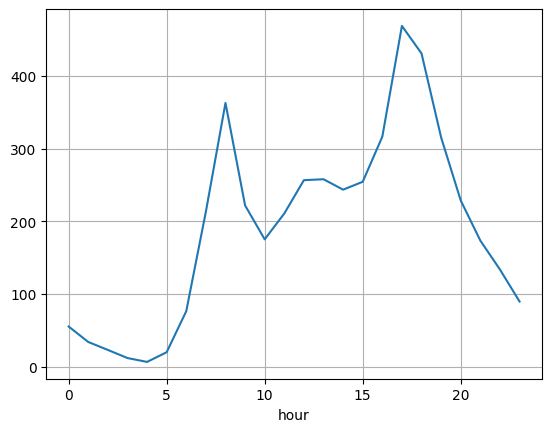

In [8]:
# Celda 2.1 - rentas promedio para cada valor de la variable "hour"
bikes.groupby('hour').total.mean().plot().grid()

Al observar la gráfica se ratifica la inferencia realizada en el punto anterior, de que el uso de las bicicletas aumenta con el transcurrir del día. De esta gráfica también se resalta el aumento de la utilización a las 8h y 17h, que probablemente coinciden con el inicio y fin de las jornadas laborales.

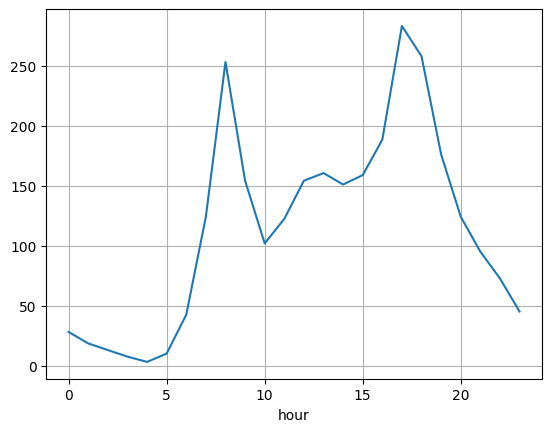

In [9]:
# Celda 2.2 - "season"=1 escriba su código y hallazgos
bikes[bikes['season']==1].groupby('hour').total.mean().plot().grid()

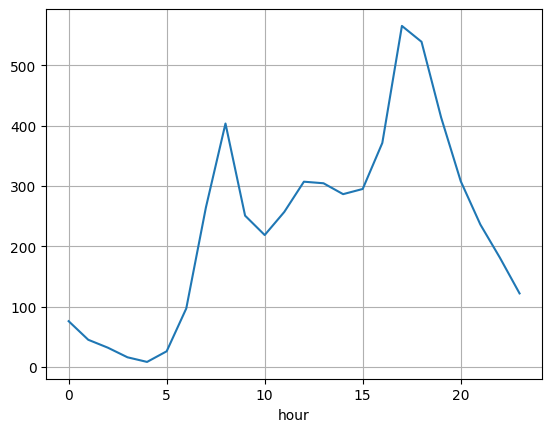

In [10]:
# Celda 2.3 - "season"=3 escriba su código y hallazgos
bikes[bikes['season']==3].groupby('hour').total.mean().plot().grid()

Al observar las gráficas del número de bicicletas rentadas promedio para cada valor de la variable "hour" durante invierno y verano, se evidencia que se presentan las mismas tendencias de uso, con aumentos al inicio y fin de la jornada laboral. Sin embargo, hay una diferencia importante en términos de cantidad: la cantidad promedio de bicicletas durante el verano es aproximadamente el doble de las utilizadas durante el invierno.

### Punto 3 - Regresión lineal
En la celda 3 ajuste un modelo de regresión lineal a un conjunto de train de datos, utilizando "total" como variable de respuesta y "season" y "hour" como las únicas variables predictoras, teniendo en cuenta que la variable "season" es categórica. Luego, imprima los coeficientes e interprételos. ¿Cuáles son las limitaciones de la regresión lineal en este caso?

In [11]:
# Celda 3
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_validate
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Lectura de datos
data = bikes.copy().reset_index()

# Selección de variables predictoras y vble de respuesta
X = data[['season', 'hour']]
y = data['total']

# Generar dummies para variable 'season' que es categórica
X = pd.get_dummies(X, columns=['season'], drop_first=True, dtype=int)

# Separar datos en train y test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0
)

# Definición del modelo
model = LinearRegression()

# Realizar cross-validation
cv_results = cross_validate(
    model,
    X_train,
    y_train,
    cv=5,
    scoring=['neg_mean_squared_error', 'r2'],
    return_train_score=True
)

# Realizar cross-validation para revisar estabilidad del modelo
cv_summary = pd.DataFrame({
    'rmse_train': np.sqrt(-cv_results['train_neg_mean_squared_error']),
    'rmse_test': np.sqrt(-cv_results['test_neg_mean_squared_error']),
    'r2_train': cv_results['train_r2'],
    'r2_test': cv_results['test_r2']
})

print(cv_summary.round(3))
print('\nPromedios CV:')
print(cv_summary.mean().round(3))

# Entrenamiento final y predicción en test
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Métricas calculas con el conjunto de datos de validación
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred))
r2_test = r2_score(y_test, y_pred)

print('\nPerformance en validación:')
print(f'RMSE val: {rmse_test:.3f}')
print(f'R2 val: {r2_test:.3f}')

coef_df = pd.DataFrame({
    'variable': list(X.columns),
    'coeficiente': list(model.coef_)
})

print('\nCoeficientes del modelo:')
print(coef_df.round(1))

   rmse_train  rmse_test  r2_train  r2_test
0     160.013    156.354     0.226    0.215
1     158.467    162.555     0.220    0.238
2     159.672    157.765     0.227    0.211
3     158.607    162.014     0.223    0.228
4     159.589    158.067     0.225    0.222

Promedios CV:
rmse_train    159.269
rmse_test     159.351
r2_train        0.224
r2_test         0.223
dtype: float64

Performance en validación:
RMSE val: 161.033
R2 val: 0.220

Coeficientes del modelo:
   variable  coeficiente
0      hour         10.5
1  season_2         99.2
2  season_3        118.6
3  season_4         86.3


El modelo presenta un desempeño limitado (R² ~0.22), en gran parte porque intenta aproximar de forma lineal una relación que es inherentemente no lineal, como lo es la variación de la demanda a lo largo del día que no puede ser capturado adecuadamente por una sola pendiente. A esto se suma la falta de variables relevantes como clima y tipo de día, lo que reduce aún más su capacidad explicativa.

En cuanto a los coeficientes, el modelo sugiere un incremento promedio de aproximadamente 10.5 bicicletas por cada hora adicional, lo que evidencia esta suposición lineal sobre una dinámica que en realidad no lo es. Por su parte, los coeficientes asociados a las estaciones muestran un efecto significativo frente al invierno (categoría base), con mayores niveles de demanda en verano (+118), primavera (+99) y otoño (+86), lo que confirma la influencia estacional en el uso del servicio.

### Punto 4 - Árbol de decisión manual
En la celda 4 cree un árbol de decisiones para pronosticar la variable "total" iterando **manualmente** sobre las variables "hour" y  "season". El árbol debe tener al menos 6 nodos finales.

In [12]:
# Celda 4

# Definición de parámetros y criterios de parada
max_depth = 4
num_pct = 10
min_gain = 0.001
min_samples_leaf = 20

# Definir cuáles variables son categóricas
categorical_features = ['season']

# Función de varianza
def variance(y):
    if y.shape[0] == 0:
        return 0
    return np.var(y)

# Ganancia por reducción de varianza
def variance_reduction_from_mask(y, filter_l):
    y_l = y.loc[filter_l]
    y_r = y.loc[~filter_l]

    n_l = y_l.shape[0]
    n_r = y_r.shape[0]
    n = n_l + n_r

    # Evitar nodos vacíos
    if n_l == 0 or n_r == 0:
        return -np.inf

    var_parent = variance(y)
    var_l = variance(y_l)
    var_r = variance(y_r)

    gain = var_parent - (n_l / n) * var_l - (n_r / n) * var_r
    return gain

# Mejor split
# Para hour se evalúan cortes por percentiles
# Para season se evalúan particiones por categoría: season == c vs resto
def best_split(X, y, num_pct=10, min_samples_leaf=20, categorical_features=None):

    if categorical_features is None:
        categorical_features = []

    best = [None, None, None, -np.inf]
    #      [j, split, split_type, gain]

    for j in range(X.shape[1]):
        col_name = X.columns[j]
        col = X.iloc[:, j]

        # Caso 1: variable categórica
        if col_name in categorical_features:
            categories = np.sort(col.unique())

            for cat in categories:
                # Split: categoría == cat vs resto
                filter_l = (col == cat)

                n_l = filter_l.sum()
                n_r = (~filter_l).sum()

                if n_l < min_samples_leaf or n_r < min_samples_leaf:
                    continue

                gain = variance_reduction_from_mask(y, filter_l)

                if gain > best[3]:
                    best = [j, cat, 'categorical_eq', gain]

        # Caso 2: variable continua
        else:
            splits = np.percentile(
                col,
                np.arange(0, 100, 100.0 / (num_pct + 1)).tolist()
            )
            splits = np.unique(splits)[1:]

            for split in splits:
                filter_l = (col < split)

                n_l = filter_l.sum()
                n_r = (~filter_l).sum()

                if n_l < min_samples_leaf or n_r < min_samples_leaf:
                    continue

                gain = variance_reduction_from_mask(y, filter_l)

                if gain > best[3]:
                    best = [j, split, 'continuous_lt', gain]

    return best

# Crecimiento recursivo del árbol
def tree_grow(X, y, level=0, min_gain=0.001, max_depth=None,
              num_pct=10, min_samples_leaf=20, categorical_features=None):

    if categorical_features is None:
        categorical_features = []

    # Predicción del nodo = promedio
    y_pred = y.mean()

    # Nodo hoja si solo queda una observación
    if X.shape[0] <= 1:
        return dict(
            y_pred=y_pred,
            level=level,
            split=-1,
            split_type=None,
            n_samples=X.shape[0],
            gain=0
        )

    # Buscar mejor split
    j, split, split_type, gain = best_split(
        X, y,
        num_pct=num_pct,
        min_samples_leaf=min_samples_leaf,
        categorical_features=categorical_features
    )

    # Crear nodo actual
    tree = dict(
        y_pred=y_pred,
        level=level,
        split=-1,
        split_type=None,
        n_samples=X.shape[0],
        gain=gain
    )

    # Criterios de parada
    if j is None:
        return tree

    if gain < min_gain:
        return tree

    if max_depth is not None and level >= max_depth:
        return tree

    # Construir máscara según tipo de split
    if split_type == 'continuous_lt':
        filter_l = (X.iloc[:, j] < split)
    elif split_type == 'categorical_eq':
        filter_l = (X.iloc[:, j] == split)
    else:
        return tree

    X_l, y_l = X.loc[filter_l], y.loc[filter_l]
    X_r, y_r = X.loc[~filter_l], y.loc[~filter_l]

    # Evitar nodos vacíos
    if X_l.shape[0] == 0 or X_r.shape[0] == 0:
        return tree

    tree['split'] = [j, split]
    tree['split_type'] = split_type

    # Crecimiento recursivo
    tree['sl'] = tree_grow(
        X_l, y_l,
        level=level + 1,
        min_gain=min_gain,
        max_depth=max_depth,
        num_pct=num_pct,
        min_samples_leaf=min_samples_leaf,
        categorical_features=categorical_features
    )

    tree['sr'] = tree_grow(
        X_r, y_r,
        level=level + 1,
        min_gain=min_gain,
        max_depth=max_depth,
        num_pct=num_pct,
        min_samples_leaf=min_samples_leaf,
        categorical_features=categorical_features
    )

    return tree

# Predicción
def tree_predict(X, tree):

    predicted = np.ones(X.shape[0]) * np.nan

    # Si es hoja
    if tree['split'] == -1:
        predicted[:] = tree['y_pred']
        return predicted

    j, split = tree['split']
    split_type = tree['split_type']

    # Aplicar regla del nodo
    if split_type == 'continuous_lt':
        filter_l = (X.iloc[:, j] < split)
    elif split_type == 'categorical_eq':
        filter_l = (X.iloc[:, j] == split)
    else:
        predicted[:] = tree['y_pred']
        return predicted

    X_l = X.loc[filter_l]
    X_r = X.loc[~filter_l]

    if X_l.shape[0] > 0:
        predicted[filter_l] = tree_predict(X_l, tree['sl'])

    if X_r.shape[0] > 0:
        predicted[~filter_l] = tree_predict(X_r, tree['sr'])

    return predicted

# Contar hojas
def count_leaves(tree):
    if tree['split'] == -1:
        return 1
    return count_leaves(tree['sl']) + count_leaves(tree['sr'])

# Entrenar árbol manual
tree = tree_grow(
    X, y,
    level=0,
    min_gain=min_gain,
    max_depth=max_depth,
    num_pct=num_pct,
    min_samples_leaf=min_samples_leaf,
    categorical_features=categorical_features
)

# Verificar hojas terminales
n_leaves = count_leaves(tree)
print("Número de hojas terminales:", n_leaves)

# Predicciones y métricas
y_pred = tree_predict(X, tree)

rmse = np.sqrt(mean_squared_error(y, y_pred))
r2 = r2_score(y, y_pred)

print("\nDesempeño del árbol manual:")
print(f"RMSE: {rmse:.3f}")
print(f"R2: {r2:.3f}")

Número de hojas terminales: 15

Desempeño del árbol manual:
RMSE: 129.112
R2: 0.492


### Punto 5 - Árbol de decisión con librería
En la celda 5 entrene un árbol de decisiones con la **librería sklearn**, usando las variables predictoras "season" y "hour" y calibre los parámetros que considere conveniente para obtener un mejor desempeño. Recuerde dividir los datos en conjuntos de entrenamiento y validación para esto. Comente el desempeño del modelo con alguna métrica de desempeño de modelos de regresión y compare desempeño con el modelo del punto 3.

Tenga en cuenta que, a diferencia del laboratorio, este problema es de regresión. Por lo tanto, para hacer cada split del árbol se debe utilizar algún criterio apropiado para problemas de regresión.

In [13]:
# Celda 5
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV

# Definición del modelo
model_dt = DecisionTreeRegressor(random_state=0)

# Hyper-parámetros para hacer tuning
param_grid = {
    'max_depth': [3, 5, 10, 15, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 5, 10]
}

# Definición y ejecución del tuning de los hyper-parámetros
grid = GridSearchCV(
    estimator=model_dt,
    param_grid=param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

grid.fit(X_train, y_train)

# Selección de mejor modelo
best_dt = grid.best_estimator_
print("Mejores parámetros:", grid.best_params_)

# Medición del desempeño con el conjunto de datos de validación
y_pred = best_dt.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f'\nRMSE validación: {rmse:.3f}')
print(f'R2 validación: {r2:.3f}')

Mejores parámetros: {'max_depth': 15, 'min_samples_leaf': 1, 'min_samples_split': 2}

RMSE validación: 115.562
R2 validación: 0.598


Para evaluar los modelos se utilizaron las métricas RMSE y R², obteniendo lo siguiente:

**Linear Regression**:
  * RMSE: 161.033
  * R2: 0.220
  
**Decision Tree**:
  * RMSE: 115.562
  * R2: 0.598

En los resultados obtenido se evidencia que el segundo modelo, el que utiliza arboles de decisión, presenta un mejor desempeño.

## Parte B - Métodos de ensamblajes
En esta parte del taller se usará el conjunto de datos de Popularidad de Noticias Online. El objetivo es predecir si la notica es popular o no, la popularidad está dada por la cantidad de reacciones en redes sociales. Para más detalles puede visitar el siguiente enlace: [datos](https://archive.ics.uci.edu/ml/datasets/online+news+popularity).

### Datos popularidad de noticias

In [14]:
# Lectura de la información de archivo .csv
df = pd.read_csv('https://raw.githubusercontent.com/davidzarruk/MIAD_ML_NLP_2023/main/datasets/mashable.csv', index_col=0)
df.head()

,url,timedelta,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,num_hrefs,num_self_hrefs,num_imgs,...,min_positive_polarity,max_positive_polarity,avg_negative_polarity,min_negative_polarity,max_negative_polarity,title_subjectivity,title_sentiment_polarity,abs_title_subjectivity,abs_title_sentiment_polarity,Popular
0,http://mashable.com/2014/12/10/cia-torture-rep...,28.0,9.0,188.0,0.732620,1.0,0.844262,5.0,1.0,1.0,...,0.200000,0.80,-0.487500,-0.60,-0.250000,0.9,0.8,0.4,0.8,1
1,http://mashable.com/2013/10/18/bitlock-kicksta...,447.0,7.0,297.0,0.653199,1.0,0.815789,9.0,4.0,1.0,...,0.160000,0.50,-0.135340,-0.40,-0.050000,0.1,-0.1,0.4,0.1,0
2,http://mashable.com/2013/07/24/google-glass-po...,533.0,11.0,181.0,0.660377,1.0,0.775701,4.0,3.0,1.0,...,0.136364,1.00,0.000000,0.00,0.000000,0.3,1.0,0.2,1.0,0
3,http://mashable.com/2013/11/21/these-are-the-m...,413.0,12.0,781.0,0.497409,1.0,0.677350,10.0,3.0,1.0,...,0.100000,1.00,-0.195701,-0.40,-0.071429,0.0,0.0,0.5,0.0,0
4,http://mashable.com/2014/02/11/parking-ticket-...,331.0,8.0,177.0,0.685714,1.0,0.830357,3.0,2.0,1.0,...,0.100000,0.55,-0.175000,-0.25,-0.100000,0.0,0.0,0.5,0.0,0


In [15]:
# Definición variable de interes y variables predictoras
X = df.drop(['url', 'Popular'], axis=1)
y = df['Popular']
y.mean()

np.float64(0.5)

In [16]:
# División de la muestra en set de entrenamiento y prueba
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=1)

### Punto 6 - Árbol de decisión y regresión logística
En la celda 6 construya un árbol de decisión y una regresión logística. Para el árbol calibre al menos un parámetro y evalúe el desempeño de cada modelo usando las métricas de Accuracy y F1-Score.

In [17]:
# Celda 6

##### Modelo Árbol de decisión
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score

# Definir el modelo
model_tree_clf = DecisionTreeClassifier(random_state=1)

# Definir y ejecutar calibración de hyper-parametros
param_grid = {
    'max_depth': [3, 5, 7, 10],
    'min_samples_leaf': [1, 5, 10]
}

grid_tree = GridSearchCV(
    estimator=model_tree_clf,
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid_tree.fit(X_train, y_train)

# Selección del mejor modelo
best_tree = grid_tree.best_estimator_
print('\nMejores hiperparámetros para el modelo Árbol de decisiones:', grid_tree.best_params_)

# Predicciones con conjunto de datos de validación
y_pred_tree = best_tree.predict(X_test)

acc_tree = accuracy_score(y_test, y_pred_tree)
f1_tree = f1_score(y_test, y_pred_tree)

print('\nDesempeño del árbol de decisión:')
print(f'Accuracy: {acc_tree:.3f}')
print(f'F1-score: {f1_tree:.3f}')

##### Modelo Regresión logística
# Definir el modelo
log_reg = LogisticRegression(random_state=1)

# Entrenamiento del modelo
log_reg.fit(X_train, y_train)

# Predicciones con conjunto de datos de validación
y_pred_log = log_reg.predict(X_test)

acc_log = accuracy_score(y_test, y_pred_log)
f1_log = f1_score(y_test, y_pred_log)

print("\nDesempeño de la regresión logística:")
print(f"Accuracy: {acc_log:.3f}")
print(f"F1-score: {f1_log:.3f}")


Mejores hiperparámetros para el modelo Árbol de decisiones: {'max_depth': 5, 'min_samples_leaf': 1}

Desempeño del árbol de decisión:
Accuracy: 0.637
F1-score: 0.662

Desempeño de la regresión logística:
Accuracy: 0.616
F1-score: 0.612


Ambos modelos presentan un desempeño moderado, sin embargo, el árbol de decisión supera a la regresión logística, lo que sugiere la presencia de relaciones no lineales en los datos. Los valores de Accuracy (0.637) y F1-score (0.66) indican que la capacidad predictiva aún es limitada.

### Punto 7 - Votación Mayoritaria
En la celda 7 elabore un esamble con la metodología de **Votación mayoritaria** compuesto por 300 muestras bagged donde:

-las primeras 100 muestras de bootstrap vienen de árboles de decisión donde max_depth tome un valor de su elección\
-las segundas 100 muestras de bootstrap vienen de árboles de decisión donde min_samples_leaf tome un valor de su elección\
-las últimas 100 muestras de bootstrap vienen de regresiones logísticas

Evalúe cada uno de los tres modelos de manera independiente utilizando las métricas de Accuracy y F1-Score, luego evalúe el ensamble de modelos y compare los resultados.

Nota:

Para este ensamble de 300 modelos, deben hacer votación mayoritaria. Esto lo pueden hacer de distintas maneras. La más "fácil" es haciendo la votación "manualmente", como se hace a partir del minuto 5:45 del video de Ejemplo práctico de emsablajes en Coursera. Digo que es la más fácil porque si hacen la votación mayoritaria sobre las 300 predicciones van a obtener lo que se espera.

Otra opción es: para cada uno de los 3 tipos de modelos, entrenar un ensamble de 100 modelos cada uno. Predecir para cada uno de esos tres ensambles y luego predecir como un ensamble de los 3 ensambles. La cuestión es que la votación mayoritaria al usar los 3 ensambles no necesariamente va a generar el mismo resultado que si hacen la votación mayoritaria directamente sobre los 300 modelos. Entonces, para los que quieran hacer esto, deben hacer ese último cálculo con cuidado.

Para los que quieran hacerlo como ensamble de ensambles, digo que se debe hacer el ensamble final con cuidado por lo siguiente. Supongamos que:

* para los 100 árboles del primer tipo, la votación mayoritaria es: 55% de los modelos predicen que la clase de una observación es "1"
* para los 100 árboles del segundo tipo, la votación mayoritaria es: 55% de los modelos predicen que la clase de una observación es "1"
* para las 100 regresiones logísticas, la votación mayoritaria es: 10% de los modelos predicen que la clase de una observación es "1"

Si se hace la votación mayoritaria de los 300 modelos, la predicción de esa observación debería ser: (100*55%+100*55%+100*10%)/300 = 40% de los modelos votan porque la predicción debería ser "1". Es decir, la predicción del ensamble es "0" (dado que menos del 50% de modelos predijo un 1).

Sin embargo, si miramos cada ensamble por separado, el primer ensamble predice "1", el segundo ensamble predice "1" y el último ensamble predice "0". Si hago votación mayoritaria sobre esto, la predicción va a ser "1", lo cual es distinto a si se hace la votación mayoritaria sobre los 300 modelos.

In [18]:
# Celda 7
step = 100
n_estimators = 300

np.random.seed(123)
n_samples = X_train.shape[0]
samples = [np.random.choice(a=n_samples, size=n_samples, replace=True) for _ in range(n_estimators)]

np.random.seed(123)
seeds = np.random.randint(1, 10000, size=n_estimators)

trees = {}
# Creación de 100 muestras de bootstrap vienen de árboles de decisión con max_depth=5
for i in range(step):
    trees[i] = DecisionTreeClassifier(max_depth=5, random_state=seeds[i])
    trees[i].fit(X_train.iloc[samples[i]], y_train.iloc[samples[i]])

# Creación de 100 muestras de bootstrap vienen de árboles de decisión con min_samples_leaf=1
for i in range(step, step*2):
    trees[i] = DecisionTreeClassifier(min_samples_leaf=1, random_state=seeds[i])
    trees[i].fit(X_train.iloc[samples[i]], y_train.iloc[samples[i]])

# Creación de 100 muestras de bootstrap vienen de regresiones logísticas
for i in range(step*2, step*3):
    trees[i] = LogisticRegression(random_state=1)
    trees[i].fit(X_train.iloc[samples[i]], y_train.iloc[samples[i]])

y_pred_df = pd.DataFrame(index=X_test.index, columns=list(range(n_estimators)))
for i in range(n_estimators):
    y_pred_df.iloc[:, i] = trees[i].predict(X_test)

display(y_pred_df.head())

# Métricas de desempeño para los modelos independientes
y_pred_mod1 = (y_pred_df.iloc[:, 0:100].sum(axis=1) >= (step / 2)).astype(np.int64)
y_pred_mod2 = (y_pred_df.iloc[:, 100:200].sum(axis=1) >= (step / 2)).astype(np.int64)
y_pred_mod3 = (y_pred_df.iloc[:, 200:300].sum(axis=1) >= (step / 2)).astype(np.int64)

acc_mod1 = accuracy_score(y_test, y_pred_mod1)
f1_mod1  = f1_score(y_test, y_pred_mod1)
print("\nDesempeño de 1er modelo (árboles de decisión con max_depth=5):")
print(f"Accuracy: {acc_mod1:.3f}")
print(f"F1-score: {f1_mod1:.3f}")

acc_mod2 = accuracy_score(y_test, y_pred_mod2)
f1_mod2  = f1_score(y_test, y_pred_mod2)
print("\nDesempeño de 2do modelo (árboles de decisión con min_samples_leaf=1):")
print(f"Accuracy: {acc_mod2:.3f}")
print(f"F1-score: {f1_mod2:.3f}")

acc_mod3 = accuracy_score(y_test, y_pred_mod3)
f1_mod3  = f1_score(y_test, y_pred_mod3)
print("\nDesempeño de 3er modelo (regresiones logísticas):")
print(f"Accuracy: {acc_mod3:.3f}")
print(f"F1-score: {f1_mod3:.3f}")

# Calculo de predicciones con votacion mayoritaria
y_pred_vot_may = (y_pred_df.sum(axis=1) >= (n_estimators / 2)).astype(np.int64)

# Métricas de desempeño del ensamble
acc_vot_may = accuracy_score(y_test, y_pred_vot_may)
f1_vot_may  = f1_score(y_test, y_pred_vot_may)

print("\nDesempeño de ensamble con Votación mayoritaria:")
print(f"Accuracy: {acc_vot_may:.3f}")
print(f"F1-score: {f1_vot_may:.3f}")

,0,1,2,3,4,5,6,7,8,9,...,290,291,292,293,294,295,296,297,298,299
1483,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
2185,1,1,0,1,1,1,1,1,1,1,...,0,0,1,0,1,1,0,0,0,0
2520,1,1,1,0,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
3721,1,1,1,0,1,1,0,1,1,1,...,1,1,1,1,1,1,1,1,1,1
3727,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0



Desempeño de 1er modelo (árboles de decisión con max_depth=5):
Accuracy: 0.655
F1-score: 0.653

Desempeño de 2do modelo (árboles de decisión con min_samples_leaf=1):
Accuracy: 0.660
F1-score: 0.667

Desempeño de 3er modelo (regresiones logísticas):
Accuracy: 0.619
F1-score: 0.612

Desempeño de ensamble con Votación mayoritaria:
Accuracy: 0.631
F1-score: 0.627


### Punto 8 - Votación Ponderada
En la celda 8 elabore un ensamble con la metodología de **Votación ponderada** compuesto por 300 muestras bagged para los mismos tres escenarios del punto 7. Evalúe los modelos utilizando las métricas de Accuracy y F1-Score

In [19]:
# Celda 8

samples_oob = []
# Obtención de las observaciones fuera de la bolsa "out-of-bag" para cada muestra
for sample in samples:
    samples_oob.append(sorted(set(range(n_samples)) - set(sample)))

# Estimación de los errores OOB para cada clasificador
errors = np.zeros(n_estimators)
acccc = np.zeros(n_estimators)

for i in range(n_estimators):
    y_pred_ = trees[i].predict(X_train.iloc[samples_oob[i]])
    errors[i] = 1 - accuracy_score(y_train.iloc[samples_oob[i]], y_pred_)

# Obtención de los pesos alpha de cada modelo de acuerdo al error OOB
alpha = (1 - errors) / (1 - errors).sum()

# Ponderación de las predicciones con los pesos alpha
weighted_sum_1 = ((y_pred_df) * alpha).sum(axis=1)

# Desempeño al hacer votación ponderada
y_pred_pon = (weighted_sum_1 >= 0.5).astype(np.int64)
acc_vot_pon = accuracy_score(y_test, y_pred_pon)
f1_vot_pon = f1_score(y_test, y_pred_pon)

print("\nDesempeño de ensamble con Votación ponderada:")
print(f"Accuracy: {acc_vot_pon:.3f}")
print(f"F1-score: {f1_vot_pon:.3f}")


Desempeño de ensamble con Votación ponderada:
Accuracy: 0.629
F1-score: 0.623


### Punto 9 - Comparación y análisis de resultados
En la celda 9 comente sobre los resultados obtenidos con las metodologías usadas en los puntos 7 y 8, compare los resultados y enuncie posibles ventajas o desventajas de cada una de ellas.

In [20]:
# Celda 9
pd.DataFrame({
    'Metodo': ['Votación Mayoritaria', 'Votación Ponderada'],
    'Accuracy': [acc_vot_may, acc_vot_pon],
    'F1-score': [f1_vot_may, f1_vot_pon]
})

,Metodo,Accuracy,F1-score
0,Votación Mayoritaria,0.630667,0.627187
1,Votación Ponderada,0.628667,0.623394


Aunque la votación ponderada busca aprovechar el desempeño diferencial de los clasificadores, en este caso no logra superar a la votación mayoritaria, lo que sugiere que los modelos base presentan comportamientos similares y que los pesos calculados no aportan una ventaja significativa. Por ello, la votación mayoritaria resulta ser una alternativa más simple y robusta para este conjunto de modelos.